# Day 2 — Data Understanding
## AI-Powered Phishing Email Detection System

This notebook documents the dataset exploration for the project: source structure,
class balance per source, the data-leakage risk discovered, and the resulting data
strategy for each module.

**Dataset:** "Phish No More" (Alam, Kaggle) — a compilation of Enron, Ling, CEAS,
Nazario, Nigerian Fraud, and SpamAssassin.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data/"
pd.set_option('display.max_colwidth', 80)


## 1. Loading and inspecting each source file

In [2]:
files = {
    "Enron": "Enron.csv",
    "Nazario": "Nazario.csv",
    "CEAS_08": "CEAS_08.csv",
    "SpamAssassin": "SpamAssasin.csv",
    "phishing_email (combined)": "phishing_email.csv",
}

dfs = {}
summary_rows = []

for name, fname in files.items():
    df = pd.read_csv(DATA_DIR + fname, on_bad_lines='skip')
    dfs[name] = df
    label_counts = df['label'].value_counts().to_dict() if 'label' in df.columns else {}
    summary_rows.append({
        "source": name,
        "rows": len(df),
        "columns": ", ".join(df.columns),
        "legit (0)": label_counts.get(0, "-"),
        "phishing (1)": label_counts.get(1, "-"),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,source,rows,columns,legit (0),phishing (1)
0,Enron,29767,"subject, body, label",15791,13976
1,Nazario,1565,"sender, receiver, date, subject, body, urls, label",-,1565
2,CEAS_08,39154,"sender, receiver, date, subject, body, label, urls",17312,21842
3,SpamAssassin,5809,"sender, receiver, date, subject, body, label, urls",4091,1718
4,phishing_email (combined),82486,"text_combined, label",39595,42891


## 2. Key finding: structural data leakage risk

Not all source files have the same columns, and — critically — **not all sources
contain both classes**:

- `Enron.csv` and `phishing_email.csv` provide **subject/body text only**, with
  both legitimate and phishing labels present and reasonably balanced.
- `CEAS_08.csv` and `SpamAssasin.csv` provide **sender, receiver, date, urls**
  *and* body/subject, again with both classes present.
- `Nazario.csv` provides sender/date/urls fields too — but **100% of its rows
  are labeled phishing (label = 1)**.

If header/URL fields from a 100%-phishing-only source were combined naively with
a text-only legitimate source, a model could learn to associate the mere
*presence* of a `urls`/`sender` field with the phishing label — a spurious,
source-correlated shortcut rather than genuine phishing signal. This would
produce misleadingly strong metrics in-sample while failing on real emails
(which always have a sender/date, phishing or not).


In [3]:
for name, df in dfs.items():
    if 'label' in df.columns:
        vc = df['label'].value_counts(normalize=True) * 100
        print(f"{name:28s} -> legit: {vc.get(0,0):5.1f}%   phishing: {vc.get(1,0):5.1f}%   (n={len(df)})")


Enron                        -> legit:  53.0%   phishing:  47.0%   (n=29767)
Nazario                      -> legit:   0.0%   phishing: 100.0%   (n=1565)
CEAS_08                      -> legit:  44.2%   phishing:  55.8%   (n=39154)
SpamAssassin                 -> legit:  70.4%   phishing:  29.6%   (n=5809)
phishing_email (combined)    -> legit:  48.0%   phishing:  52.0%   (n=82486)


## 3. Class balance — visualized

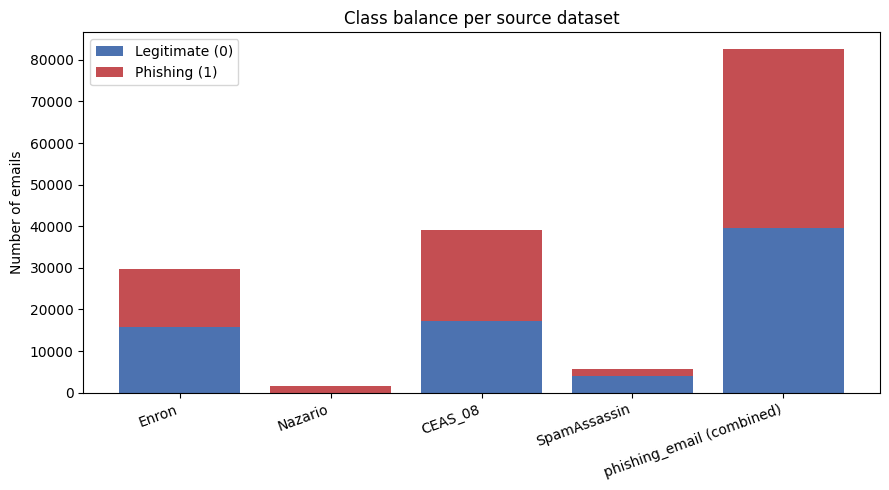

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
sources = list(dfs.keys())
legit_counts = [dfs[s]['label'].value_counts().get(0,0) for s in sources]
phish_counts = [dfs[s]['label'].value_counts().get(1,0) for s in sources]

x = range(len(sources))
ax.bar(x, legit_counts, label='Legitimate (0)', color='#4C72B0')
ax.bar(x, phish_counts, bottom=legit_counts, label='Phishing (1)', color='#C44E52')
ax.set_xticks(list(x))
ax.set_xticklabels(sources, rotation=20, ha='right')
ax.set_ylabel('Number of emails')
ax.set_title('Class balance per source dataset')
ax.legend()
plt.tight_layout()
plt.savefig('class_balance.png', dpi=120)
plt.show()


## 4. Data strategy per module (decision resulting from the above)

| Module | Dataset(s) used | Rationale |
|---|---|---|
| NLP text classifier | `phishing_email.csv` (primary), `Enron.csv` (supplementary) | Both classes present, consistent text-only columns, large sample size (~82k) |
| Header Parser | `CEAS_08.csv`, `SpamAssasin.csv` | Both classes present *with* sender/receiver/date fields — no source-correlated leakage |
| URL Extraction & Reputation | `CEAS_08.csv`, `SpamAssasin.csv` | Both classes present with a `urls` field populated |
| Qualitative-only testing | `Nazario.csv` (and `Nigerian_Fraud.csv`, pending inspection) | 100% phishing — useful to sanity-check that known phishing headers/URLs are correctly flagged, but **not used to train/evaluate a binary classifier** |

**Not yet inspected:** `Ling.csv`, `Nigerian_Fraud.csv` — pending upload, low
priority since the data strategy above does not depend on them.


## 5. Data quality note

Initial inspection of `CEAS_08.csv` revealed clearly invalid dates (e.g. year
2100, year 1980 outliers), indicating the compiled dataset was not perfectly
cleaned during construction. **Decision:** raw date fields will not be used
directly as model features without further validation/cleaning.


In [5]:
# Confirm the date anomaly noted during manual inspection
ceas = dfs["CEAS_08"]
if 'date' in ceas.columns:
    print(ceas['date'].sample(5, random_state=1).to_list())


['Wed, 06 Aug 2008 01:50:27 -0300', 'Thu, 07 Aug 2008 07:54:22 +0000', 'Wed, 06 Aug 2008 01:53:53 +0100', 'Wed, 06 Aug 2008 09:59:42 +0600', 'Wed, 06 Aug 2008 14:28:33 +0300']


## 6. Sample inspection — 5 legitimate + 5 phishing (text)

In [6]:
combined = dfs["phishing_email (combined)"]
legit_samples = combined[combined['label'] == 0].sample(5, random_state=42)
phish_samples = combined[combined['label'] == 1].sample(5, random_state=42)

print("=== LEGITIMATE SAMPLES ===")
for i, row in legit_samples.iterrows():
    print("-", row['text_combined'][:160].replace(chr(10), ' '), "...")

print()
print("=== PHISHING SAMPLES ===")
for i, row in phish_samples.iterrows():
    print("-", row['text_combined'][:160].replace(chr(10), ' '), "...")


=== LEGITIMATE SAMPLES ===
- ned deily riyacmorg article 51951867168434095nz5d8bhudamiredorg mike meyer wrote thu 28 feb 2008 234249 0000 utc medhat gayed wrote lxml good written python dif ...
- perl jobs xycnvtnhzperlorg online url job httpjobsperlorgjob7990 subscribe list send mail jobssubscribeperlorg unsubscribe send mail jobsunsubscribeperlorg post ...
- model 04 28 good morning bill 4 28 could move 100 bookouts 5 6 6 00 top direct bill cuts psco deals keeping together also today end month probably checking amy  ...
- request historical curve information sure already taking care thanks paulo issler vince j kaminski 11 15 2000 09 59 paulo issler hou ect ect cc subject request  ...
- ted leung wxvrjpezsuncom communityone free open developer conference run sun day javaone year space communityone dedicated python community complete whiteboards ...

=== PHISHING SAMPLES ===
- angel guerra dwtheballoonroommtheballoonroomnet pe bj nis en dh large xig ment work order top pen tu patches w

## 7. Ethical / legal note on data sourcing

This project uses only **publicly available, established academic/research
email datasets** (Enron corpus, SpamAssassin public corpus, Nazario phishing
archive, CEAS anti-spam shared task data, and the Ling-Spam corpus), not real
personal or organizational inboxes. These datasets:

- Were collected and released specifically for security/NLP research purposes
- Do not require accessing anyone's live, private email account
- Are widely cited in academic phishing-detection literature, which supports
  reproducibility and comparison against prior work

No live scraping of personal inboxes, impersonation of real individuals, or
collection of new personal data was performed for this project. The Enron
corpus in particular is a well-known exception in NLP research: it was made
public as part of a legal proceeding and has since been established as a
standard, ethically-accepted research resource.


## 8. Day 2 summary

- Verified structure, size, and class balance of 5 of 7 source files
- Identified and resolved a source-correlated data leakage risk before any
  model training occurred
- Defined a per-module data strategy grounded in what each source can
  actually support
- Identified a data quality issue (invalid dates) and made an explicit
  decision not to use raw dates as a feature
- Documented the ethical basis for using these datasets

**Next (Day 3):** environment & architecture setup — repo structure, Flask/MySQL/React
skeletons, and the system architecture diagram.
